# Análisis Exploratorio de Redes Sociales y Resultados Electorales

Este notebook realiza un análisis integrando los datos unificados de Facebook, TikTok y Twitter con los resultados electorales oficiales.

## **1. Análisis por interacciones totales**

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from scipy import stats
import statsmodels.formula.api as smf
from scipy.stats import mannwhitneyu
from sklearn.linear_model import HuberRegressor
from sklearn.metrics import r2_score
import math

# Configuración de visualización
sns.set_theme(style="whitegrid")
%matplotlib inline

# Definición de rutas
base_path = os.getcwd()
resultados_path = os.path.join(base_path, 'resultados')
excel_path = os.path.join(os.path.dirname(base_path), 'Colombia', 'Resultados electorales.xlsx')
csv_unificado = os.path.join(resultados_path, 'redes_unificadas.csv')
csv_seguidores = os.path.join(resultados_path, 'seguidores.csv')

## 1. Carga de Datos

In [132]:
# Cargar datos de redes sociales
df_redes = pd.read_csv(csv_unificado, sep=';', encoding='utf-8-sig')

# Cargar datos electorales
df_electoral = pd.read_excel(excel_path, sheet_name='Candidatos E-26 ALC')
df_electoral = df_electoral.rename(columns={'ID Candidato': 'id_candidato'})

# Cargar datos de población
df_población = pd.read_excel(excel_path, sheet_name='Población 2023 (DANE)')

# Cargar datos de seguidores
df_seguidores = pd.read_csv(csv_seguidores, sep=';', encoding = 'utf-8-sig')

# Eliminamos Piedecuesta por no tener las condiciones necesarias (Su candidato ganador eliminó sus redes sociales)
df_redes = df_redes[~df_redes["id_candidato"].str.contains("68547", na=False)]

# Eliminamos Barrancabermeja porque el candidato ganador no tuvo una cuenta realmente activa
df_redes = df_redes[~df_redes["id_candidato"].str.contains("68081", na=False)]

print(f"Redes: {df_redes.shape}")
print(f"Electoral: {df_electoral.shape}")
print(f"Número de seguidores: {df_seguidores.shape}")
print(f"información municipal: {df_población.shape}")

Redes: (8684, 18)
Electoral: (350, 9)
Número de seguidores: (123, 11)
información municipal: (36, 6)


## 2. Integración de Datos (Merge)

In [139]:
# Añadir población al dataset electoral
df_electoral = pd.merge(
    df_electoral,
    df_población[['DIVIPOLA','Población 2023']],
    on = 'DIVIPOLA',
    how ='left'
)

# Reemplazamos los NaN por 0 en el dataset de seguidores
df_seguidores = df_seguidores.fillna(0)

# Añadir seguidores al dataset electoral
df_redes_seguidores = pd.merge(
    df_redes,
    df_seguidores[['id_candidato', 'tiktok_followers','twitter_followers','facebook_followers']],
    on = 'id_candidato',
    how ='left'
)

# Combinar ambos datasets
df_completo = pd.merge(
    df_redes_seguidores, 
    df_electoral[['id_candidato', 'Candidato', 'Ganador', 'Votos','DIVIPOLA','Población 2023']], 
    on='id_candidato', 
    how='left'
)

# Mostramos todas las columnas
pd.set_option('display.max_columns', None)


# Calcular métrica de interacciones totales por post
interact_cols = ['likes', 'comentarios', 'compartidos', 'favoritos', 'fb_haha', 'fb_care', 'fb_wow', 'fb_sad', 'fb_angry']
df_completo['interacciones_totales'] = df_completo[interact_cols].sum(axis=1)

## 3. Análisis por Candidato
¿Quiénes tienen mayor tracción en redes?

...¿Y por red social? 

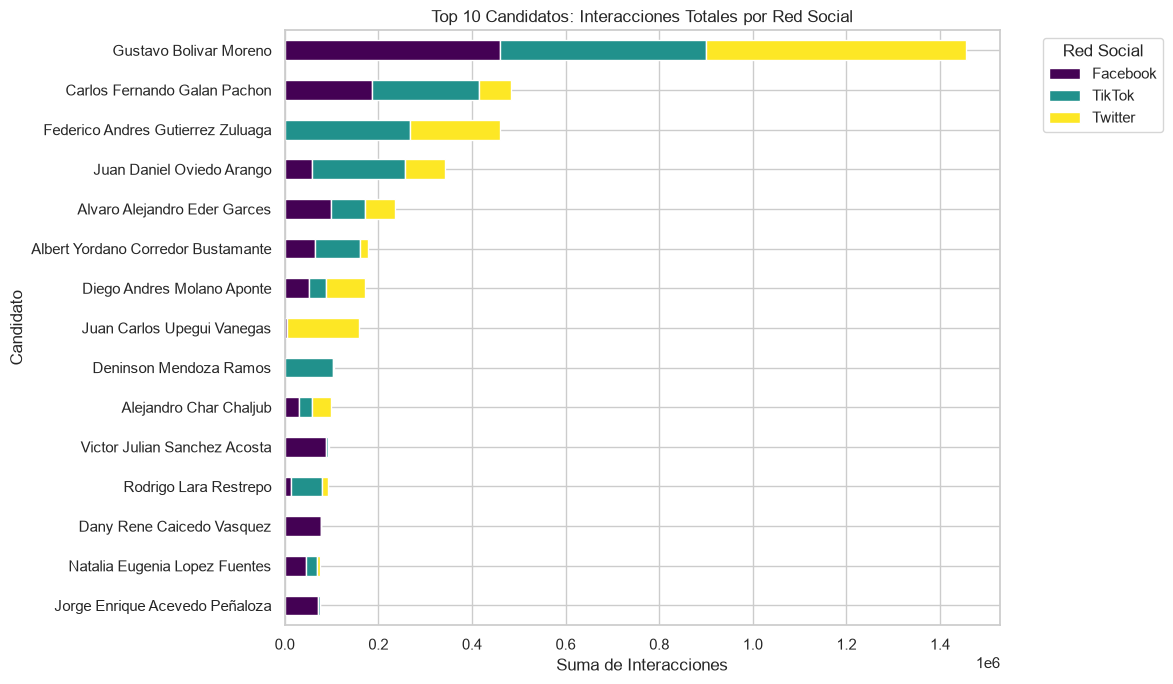

In [95]:
top_nombres = df_completo.groupby('Candidato')['interacciones_totales'].sum().sort_values(ascending=False).head(15).index
df_top = df_completo[df_completo['Candidato'].isin(top_nombres)]
grafico_data = df_top.groupby(['Candidato', 'red_social'])['interacciones_totales'].sum().unstack().fillna(0)
grafico_data = grafico_data.loc[top_nombres]
grafico_data.plot(kind='barh', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Top 10 Candidatos: Interacciones Totales por Red Social')
plt.xlabel('Suma de Interacciones')
plt.ylabel('Candidato')
plt.gca().invert_yaxis()
plt.legend(title='Red Social', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Listo, en primer lugar, teniendo en cuenta que, Federico Gutierrez, Alvaro Eder, Alejandro Char y otros candidatos ganadores tienen más interacciones que los no ganadores en sus ciudades, notable excepción es Gustavo Bolívar, por ser escritor y creador de contenido de carrera antes de entrar. Por lo tanto, ahora, podemos *sospechar* que los candidatos ganadores recibieron más interacciones que los candidatos no ganadores. Ahora, vamos a verlo más claramente. 

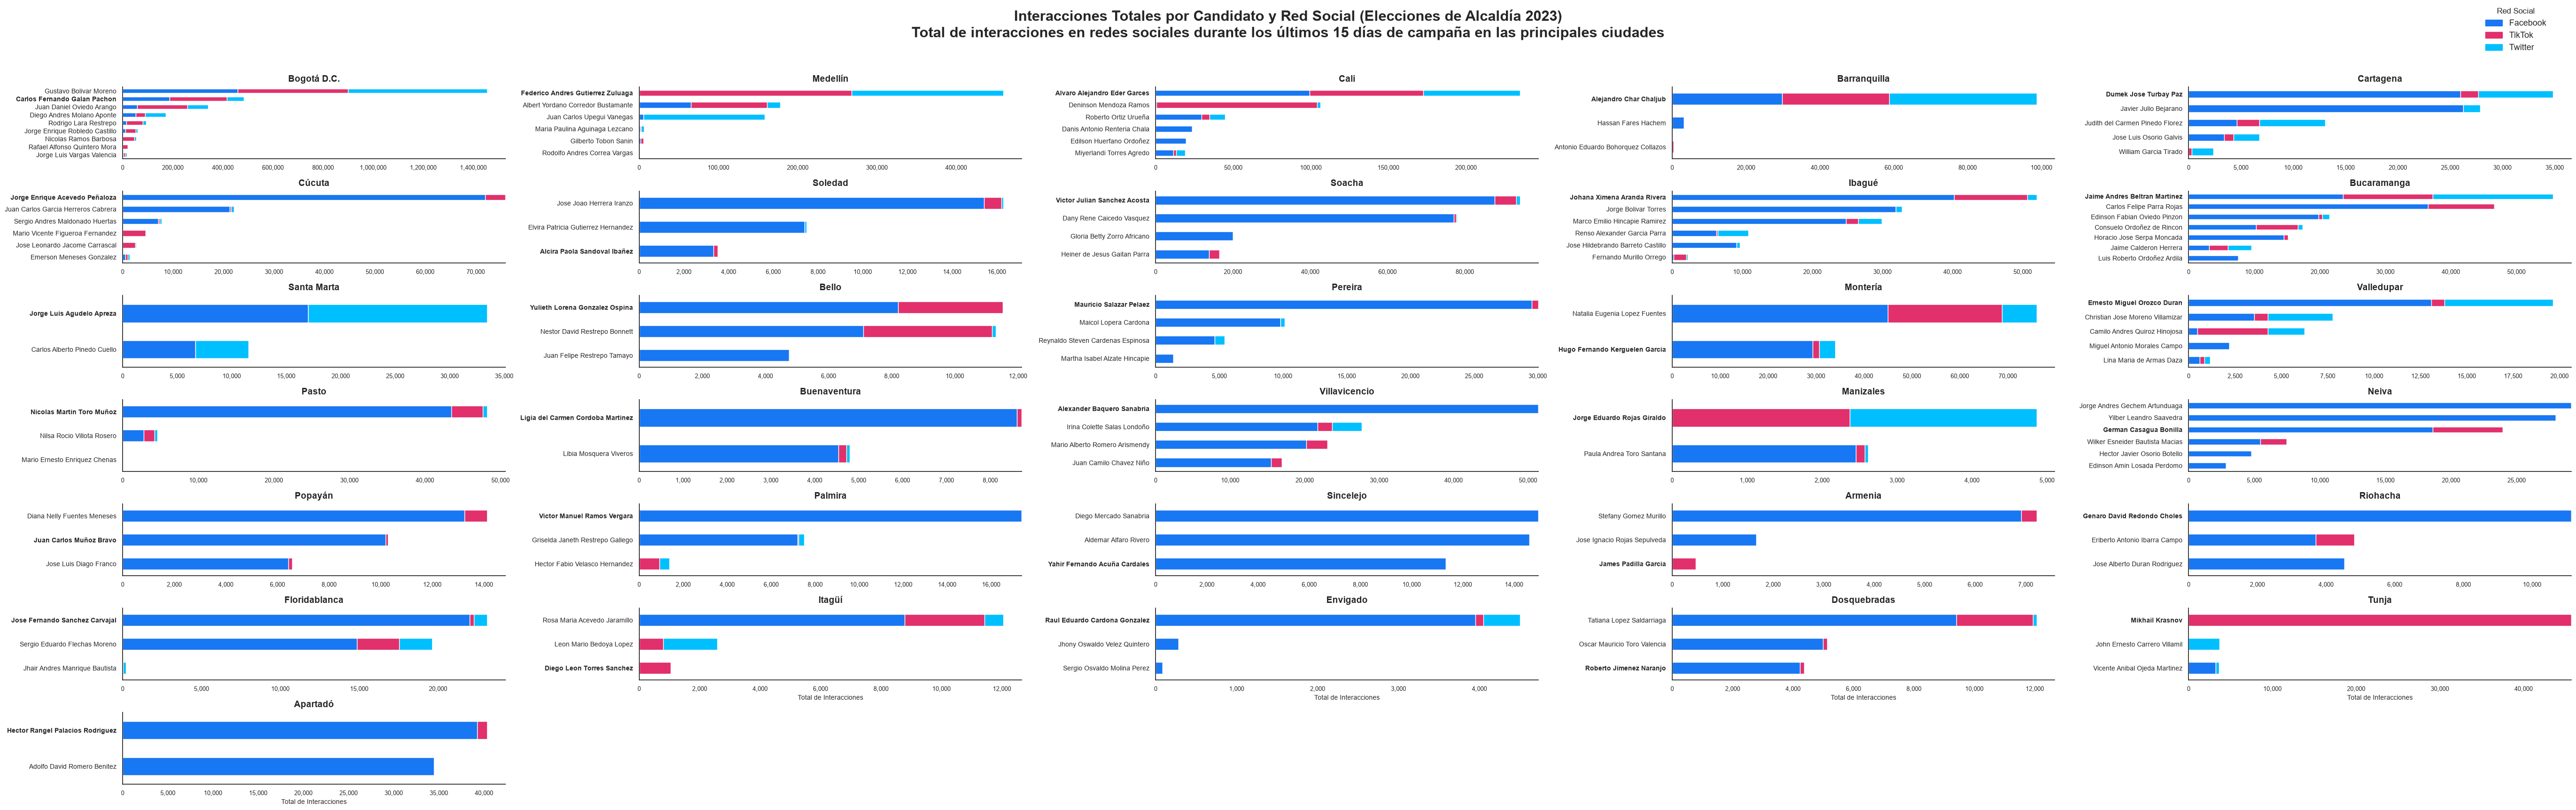

In [154]:
# 1. Asegurarnos de tener DIVIPOLA en ambos DataFrames y en formato texto (str)
if 'DIVIPOLA' not in df_completo.columns:
    df_completo['DIVIPOLA'] = df_completo['id_candidato'].astype(str).str.split('-').str[1].str.zfill(5)
else:
    df_completo['DIVIPOLA'] = df_completo['DIVIPOLA'].astype(str).str.zfill(5)

# Forzamos a que en la tabla de población también sea texto para evitar el ValueError en el merge
df_poblacion['DIVIPOLA'] = df_poblacion['DIVIPOLA'].astype(str).str.zfill(5)

# 2. Integrar el nombre del municipio cruzando con df_poblacion
df_grafica = df_completo.merge(df_poblacion[['DIVIPOLA', 'Municipio', 'Población 2023']], on='DIVIPOLA', how='left')

# 3. Seleccionar las ciudades 
# (Como quitaste el .head(6), esto ordenará y tomará todas las ciudades. Si son demasiadas, puedes agregar .head(30) al final)
col_pob = 'Población 2023' if 'Población 2023' in df_grafica.columns else 'Población 2023_x'
top_ciudades = df_grafica[['DIVIPOLA', 'Municipio', col_pob]].drop_duplicates().sort_values(by=col_pob, ascending=False)

# 4. Filtrar los datos solo para esas ciudades
df_top_ciudades = df_grafica[df_grafica['DIVIPOLA'].isin(top_ciudades['DIVIPOLA'])]

# 5. Configurar la figura para tener 5 COLUMNAS
ncols = 5
nrows = math.ceil(len(top_ciudades) / ncols)

# Ajustar el ancho a 55 para dar espacio a las 3 columnas, y la altura proporcional al número de filas
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(55, 2.5 * nrows))
axes = axes.flatten() # Aplanar el arreglo para iterar más fácil

# Colores de las redes
colores_redes = {'Facebook': '#1877F2', 'TikTok': '#E1306C', 'Twitter': '#00BFFF'} 

for idx, ax in enumerate(axes):
    if idx < len(top_ciudades):
        row = top_ciudades.iloc[idx]
        divipola_ciudad = row['DIVIPOLA']
        nombre_ciudad = row['Municipio']
        
        # Datos específicos de la ciudad
        df_ciudad = df_top_ciudades[df_top_ciudades['DIVIPOLA'] == divipola_ciudad]
        top_candidatos_ciudad = df_ciudad.groupby('Candidato')['interacciones_totales'].sum().sort_values(ascending=False).index
        grafico_data = df_ciudad.groupby(['Candidato', 'red_social'])['interacciones_totales'].sum().unstack().fillna(0)
        grafico_data = grafico_data.reindex(top_candidatos_ciudad)
        
        # Gráfica de barras
        grafico_data.plot(kind='barh', stacked=True, ax=ax, color=[colores_redes.get(x, '#333333') for x in grafico_data.columns])
        
        ax.set_title(f'{nombre_ciudad}', fontsize=14, fontweight='bold', pad=8)
        ax.set_ylabel('')
        
        # Etiqueta X solo en la última fila para no saturar la vista
        if idx >= len(top_ciudades) - ncols:
            ax.set_xlabel('Total de Interacciones', fontsize=10)
        else:
            ax.set_xlabel('')
            
        ax.invert_yaxis()
        
        # Poner en NEGRILLA al candidato ganador
        for label in ax.get_yticklabels():
            candidato = label.get_text()
            is_winner = df_ciudad[df_ciudad['Candidato'] == candidato]['Ganador'].values[0]
            if is_winner == 1 or str(is_winner).strip().lower() in ['sí', 'si', 'true']:
                label.set_fontweight('bold')
        
        # Limpieza visual de la cuadrícula
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='y', labelsize=10)
        ax.tick_params(axis='x', labelsize=9)
        ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
        
        # Quitamos la leyenda individual para poner una global al final
        if ax.get_legend() is not None:
            ax.get_legend().remove()
    else:
        # Si la cuadrícula tiene espacios sobrantes, los ocultamos
        ax.set_visible(False) 

# 6. Título y Leyenda Global
titulo = 'Interacciones Totales por Candidato y Red Social (Elecciones de Alcaldía 2023)'
subtitulo = 'Total de interacciones en redes sociales durante los últimos 15 días de campaña en las principales ciudades'
fig.suptitle(f"{titulo}\n{subtitulo}", fontsize=22, fontweight='bold')

# Arreglo del "agujero blanco" con tight_layout y control del espacio horizontal/vertical
fig.tight_layout(rect=[0, 0, 1, 0.96]) # El 0.96 deja justo el espacio arriba para el título
fig.subplots_adjust(wspace=0.35, hspace=0.45) 

# Leyenda global (arriba a la derecha)
redes_presentes = df_top_ciudades['red_social'].unique()
handles = [plt.Rectangle((0,0),1,1, color=colores_redes.get(red, '#333333')) for red in redes_presentes]
fig.legend(handles, redes_presentes, title='Red Social', loc='upper right', bbox_to_anchor=(0.99, 0.99), fontsize=13, frameon=False)

plt.show()



## 5. Relación entre Interacciones y Éxito Electoral
¿Los ganadores tienen mejores métricas?

In [143]:
# Agrupación por persona
stats_candidato = df_completo.groupby(['id_candidato', 'Candidato', 'Ganador']).agg({
    'interacciones_totales': 'sum',
    'id_candidato': 'count', # num publicaciones
    'Votos': 'first'
}).rename(columns={'id_candidato': 'num_posts'}).reset_index()

stats_candidato['interacciones_promedio'] = (stats_candidato['interacciones_totales'] / stats_candidato['num_posts']).round(2)

# Comparativa Ganadores vs No Ganadores
stats_candidato.groupby('Ganador')[['interacciones_totales', 'interacciones_promedio', 'num_posts', 'Votos']].mean().round(2)

,interacciones_totales,interacciones_promedio,num_posts,Votos
Ganador,,,,
No,41211.00,395.16,68.33,45036.07
Sí,65449.87,838.18,83.97,153129.97


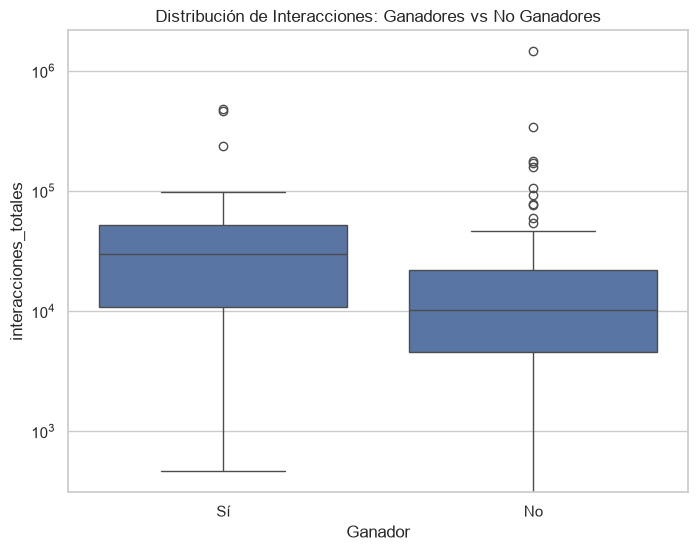

In [98]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Ganador', y='interacciones_totales', data=stats_candidato)
plt.title('Distribución de Interacciones: Ganadores vs No Ganadores')
plt.yscale('log') # Escala logarítmica para mejor visualización
plt.show()

In [99]:
# 1. Separar los grupos
ganadores = stats_candidato[stats_candidato['Ganador'] == 'Sí']['interacciones_totales']
no_ganadores = stats_candidato[stats_candidato['Ganador'] == 'No']['interacciones_totales']

# 2. Ejecutar la prueba de Mann-Whitney U
stat, p_value = mannwhitneyu(ganadores, no_ganadores, alternative='two-sided')

# 3. Mostrar resultados
print(f"Estadístico U: {stat}")
print(f"P-Valor: {p_value:.4f}")

# 4. Interpretación científica
alpha = 0.01
if p_value < alpha:
    print("\n CONCLUSIÓN: La diferencia ES estadísticamente significativa con 98% de confianza.")
    print("Hay evidencia suficiente para decir que ganar las elecciones está relacionado con el volumen de interacciones.")
else:
    print("\n CONCLUSIÓN: La diferencia NO es estadísticamente significativa con 98% de confianza.")
    print("A pesar de los promedios, no podemos decir que los ganadores tengan consistentemente más interacciones que los perdedores.")

# 5. Ver medianas (son más confiables que los promedios en este caso)
print(f"\nMediana Ganadores: {ganadores.median()}")
print(f"Mediana No Ganadores: {no_ganadores.median()}")


Estadístico U: 1860.0
P-Valor: 0.0040

 CONCLUSIÓN: La diferencia ES estadísticamente significativa con 98% de confianza.
Hay evidencia suficiente para decir que ganar las elecciones está relacionado con el volumen de interacciones.

Mediana Ganadores: 30047.0
Mediana No Ganadores: 10116.0


Comprobamos estadísticamente que existe una diferencia significativa entre perdedores y ganadores en su número total de interacciones. Ahora, deberíamos ver si esto sigue aplicando al usar el % de interacciones entre todos los candidatos de la misma carrera

Promedios por grupo:
         porcentaje_interacciones  interacciones_totales  \
Ganador                                                    
No                          17.84               41211.00   
Sí                          48.78               65449.87   

         interacciones_promedio  num_posts      Votos  
Ganador                                                
No                       395.16      68.33   45036.07  
Sí                       838.18      83.97  153129.97  


C:\Users\juansoag\AppData\Local\Temp\ipykernel_4212\1432878540.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Ganador', y='porcentaje_interacciones', data=stats_candidato, palette='Set2')


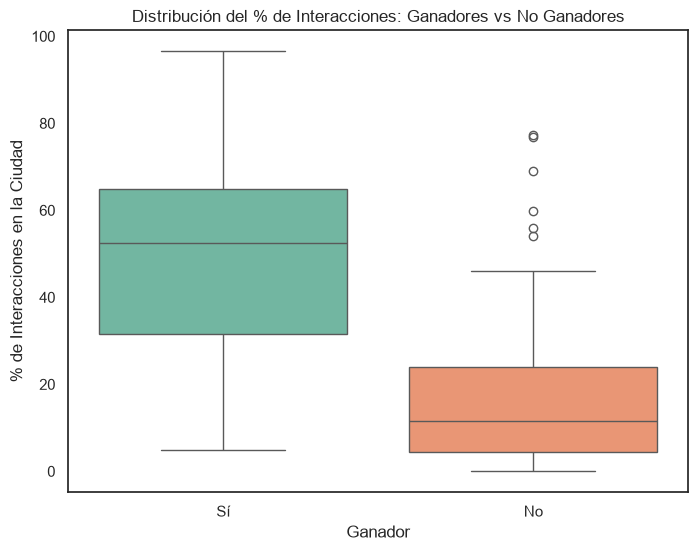

Estadístico U: 2341.5
P-Valor: 0.0000

CONCLUSIÓN: La diferencia ES estadísticamente significativa con 98% de confianza.
Hay evidencia suficiente para decir que ganar las elecciones está relacionado con tener un mayor % de las interacciones de la ciudad.

Mediana Ganadores: 52.44%
Mediana No Ganadores: 11.5%


In [155]:
# 1. Agrupación por persona y municipio (Agregamos DIVIPOLA para no perder la ciudad)
stats_candidato = df_completo.groupby(['DIVIPOLA', 'id_candidato', 'Candidato', 'Ganador']).agg({
    'interacciones_totales': 'sum',
    'id_candidato': 'count', # num publicaciones
    'Votos': 'first'
}).rename(columns={'id_candidato': 'num_posts'}).reset_index()

stats_candidato['interacciones_promedio'] = (stats_candidato['interacciones_totales'] / stats_candidato['num_posts']).round(2)

# 2. Calcular el % de interacciones del candidato respecto al total de su ciudad
# Obtenemos la suma de interacciones agrupando por ciudad
totales_ciudad = stats_candidato.groupby('DIVIPOLA')['interacciones_totales'].transform('sum')

# Calculamos el porcentaje
stats_candidato['porcentaje_interacciones'] = (stats_candidato['interacciones_totales'] / totales_ciudad) * 100
stats_candidato['porcentaje_interacciones'] = stats_candidato['porcentaje_interacciones'].fillna(0).round(2)

# Comparativa Ganadores vs No Ganadores
resumen = stats_candidato.groupby('Ganador')[['porcentaje_interacciones', 'interacciones_totales', 'interacciones_promedio', 'num_posts', 'Votos']].mean().round(2)
print("Promedios por grupo:")
print(resumen)

# 3. Gráfica de caja (Boxplot)
plt.figure(figsize=(8, 6))
# Usamos el porcentaje en el eje Y
sns.boxplot(x='Ganador', y='porcentaje_interacciones', data=stats_candidato, palette='Set2')
plt.title('Distribución del % de Interacciones: Ganadores vs No Ganadores')
plt.ylabel('% de Interacciones en la Ciudad')
# (Eliminada la escala logarítmica porque los porcentajes van de 0 a 100 y se ven bien de forma lineal)
plt.show() 

# 4. Prueba Estadística (Mann-Whitney U) usando el porcentaje
# Separar los grupos
ganadores = stats_candidato[stats_candidato['Ganador'] == 'Sí']['porcentaje_interacciones']
no_ganadores = stats_candidato[stats_candidato['Ganador'] == 'No']['porcentaje_interacciones']

# Ejecutar la prueba de Mann-Whitney U
stat, p_value = mannwhitneyu(ganadores, no_ganadores, alternative='two-sided')

# Mostrar resultados
print(f"Estadístico U: {stat}")
print(f"P-Valor: {p_value:.4f}")

# Interpretación científica
alpha = 0.01
if p_value < alpha:
    print("\nCONCLUSIÓN: La diferencia ES estadísticamente significativa con 98% de confianza.")
    print("Hay evidencia suficiente para decir que ganar las elecciones está relacionado con tener un mayor % de las interacciones de la ciudad.")
else:
    print("\nCONCLUSIÓN: La diferencia NO es estadísticamente significativa con 98% de confianza.")
    print("A pesar de los promedios, no podemos decir que los ganadores concentren consistentemente un mayor % de interacciones que los perdedores.")

# Ver medianas
print(f"\nMediana Ganadores: {ganadores.median()}%")
print(f"Mediana No Ganadores: {no_ganadores.median()}%")


Con esto, ya podemos comprobar la relación entre el estado binario de victoria con el número y dominancia de las interacciones entre los candidatos de la misma ciudad, ahora pasamos a ver como luce la dominancia local a nivel ciudad.

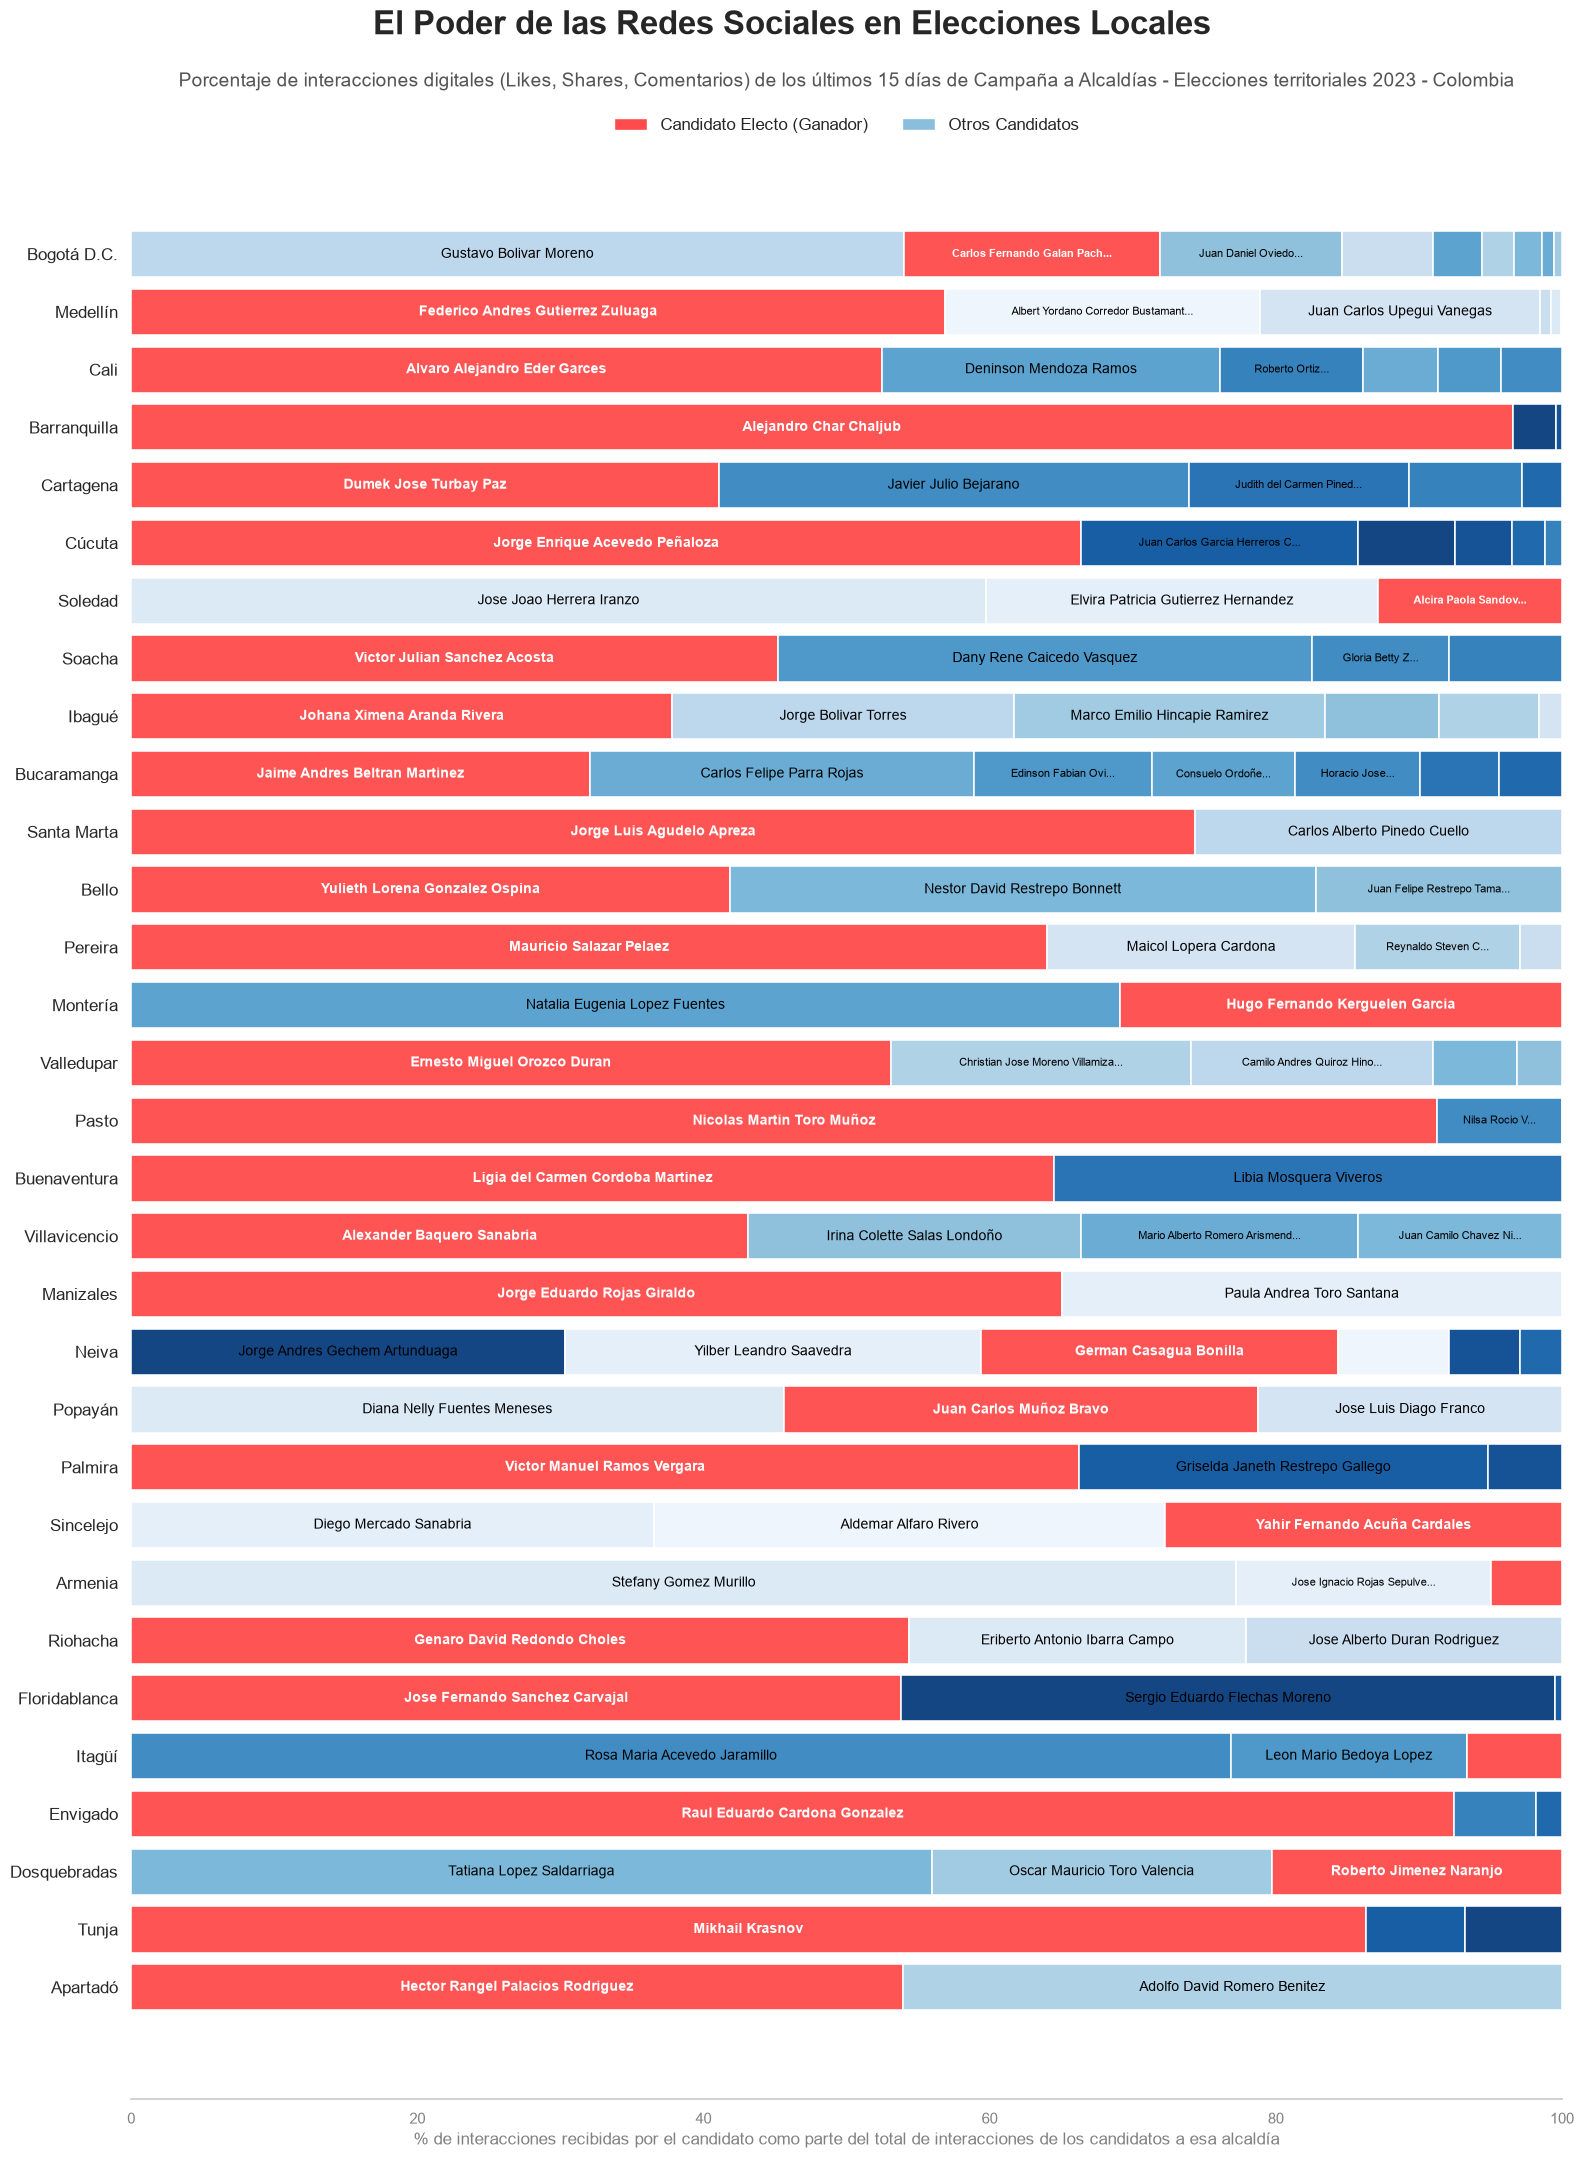

In [ ]:
# 1. Cargar y Limpiar Población (Asegurando formato 05001)
df_poblacion = pd.read_excel(excel_path, sheet_name='Población 2023 (DANE)')
df_poblacion['DIVIPOLA'] = pd.to_numeric(df_poblacion['DIVIPOLA'], errors='coerce').fillna(0).astype(int).astype(str).str.zfill(5)

# 2. Preparar Candidatos (Extraer DIVIPOLA y calcular interacciones totales)
df_completo['DIVIPOLA'] = df_completo['id_candidato'].astype(str).str.split('-').str[1].str.zfill(5)
interact_cols = ['likes', 'comentarios', 'compartidos', 'favoritos', 'fb_haha', 'fb_care', 'fb_wow', 'fb_sad', 'fb_angry']
df_completo['interacciones_totales'] = df_completo[interact_cols].sum(axis=1)

# 3. Agrupar y Calcular Porcentajes
df_muni_stats = df_completo.groupby(['DIVIPOLA', 'Candidato', 'Ganador'])['interacciones_totales'].sum().reset_index()
totales_ciudad = df_muni_stats.groupby('DIVIPOLA')['interacciones_totales'].transform('sum')
df_muni_stats['porcentaje'] = (df_muni_stats['interacciones_totales'] / totales_ciudad) * 100

# 4. Obtener ranking de ciudades por población
ranking_ciudades = df_poblacion.sort_values(by='Población 2023', ascending=False)
ciudades_con_datos = df_muni_stats['DIVIPOLA'].unique()
ranking_filtrado = ranking_ciudades[ranking_ciudades['DIVIPOLA'].isin(ciudades_con_datos)]

# 5. Configuración de la Gráfica (Estilo LinkedIn)
sns.set_theme(style="white") # Fondo blanco, limpio
fig, ax = plt.subplots(figsize=(16, 22))

# Eliminar bordes para un look más moderno
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')

competidor_palette = sns.color_palette("Blues", n_colors=20)
rojo_ganador = "#FF4B4B" # Un rojo más vibrante para llamar la atención en el feed

for i, (idx, row_pop) in enumerate(ranking_filtrado.iterrows()):
    divi = row_pop['DIVIPOLA']
    nombre_muni = row_pop['Municipio']
    
    df_m = df_muni_stats[df_muni_stats['DIVIPOLA'] == divi].sort_values(by='porcentaje', ascending=False)
    
    left = 0
    for j, row in df_m.iterrows():
        es_ganador = row['Ganador'] == 'Sí'
        color = rojo_ganador if es_ganador else competidor_palette[j % 20]
        
        ax.barh(nombre_muni, row['porcentaje'], left=left, color=color, 
                edgecolor='white', linewidth=1.2, alpha=0.95)
        
        # Etiqueta de nombre y apellido si el segmento es representativo (>8%)
        if row['porcentaje'] > 8:
            nombre_completo = str(row['Candidato'])
            
            # Estimamos un máximo de caracteres que caben según el porcentaje (ancho de la barra)
            max_chars = int(row['porcentaje'] * 1.5)
            
            # Si el nombre es muy largo, reducimos la letra y lo cortamos
            if len(nombre_completo) > max_chars:
                nombre_mostrar = nombre_completo[:max_chars].strip() + "..."
                fontsize = 8
            else:
                nombre_mostrar = nombre_completo
                fontsize = 10
                
            # Ajuste de color y peso de fuente para el ganador
            text_color = 'white' if es_ganador else 'black'
            weight = 'bold' if es_ganador else 'normal'
            
            ax.text(left + row['porcentaje']/2, i, nombre_mostrar, 
                    va='center', ha='center', color=text_color, fontsize=fontsize, weight=weight)
            
        left += row['porcentaje']

# Elementos de la leyenda
legend_elements = [
    Patch(facecolor=rojo_ganador, edgecolor='white', label='Candidato Electo (Ganador)'),
    Patch(facecolor=competidor_palette[8], edgecolor='white', label='Otros Candidatos')
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.02), 
          ncol=2, frameon=False, fontsize=12)

# Títulos y subtítulos con Storytelling
plt.suptitle('El Poder de las Redes Sociales en Elecciones Locales', 
             fontsize=24, fontweight='bold', x=0.5, y=0.98)
ax.set_title('Porcentaje de interacciones digitales (Likes, Shares, Comentarios) de los últimos 15 días de Campaña a Alcaldías - Elecciones territoriales 2023 - Colombia', 
             fontsize=14, color='#555555', pad=40)

# Configuraciones de los ejes
ax.set_xlabel('% de interacciones recibidas por el candidato como parte del total de interacciones de los candidatos a esa alcaldía', fontsize=12, color='gray')
ax.set_xlim(0, 100)
ax.invert_yaxis() 
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', colors='gray', labelsize=11)

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Espacio para que respire el título
plt.show()



Podemos ver que, con la notable excepción de Bogotá, parece que mientras más grande es una ciudad, hay más probabilidades de que el ganador también sea el que tenga más interacciones. En las primeras 10 solo 2 ciudades no tuvieron esto, de la ciudad 10 a la 20, solo 2 y de la 20 a la 30 cinco ciudades no tuvieron al candidato dominante en redes como victorioso. Ahora, podríamos suponer que puede existir una correlación entre la intención de voto y las interacciónes porcentuales, pasamos a comprobarlo. 

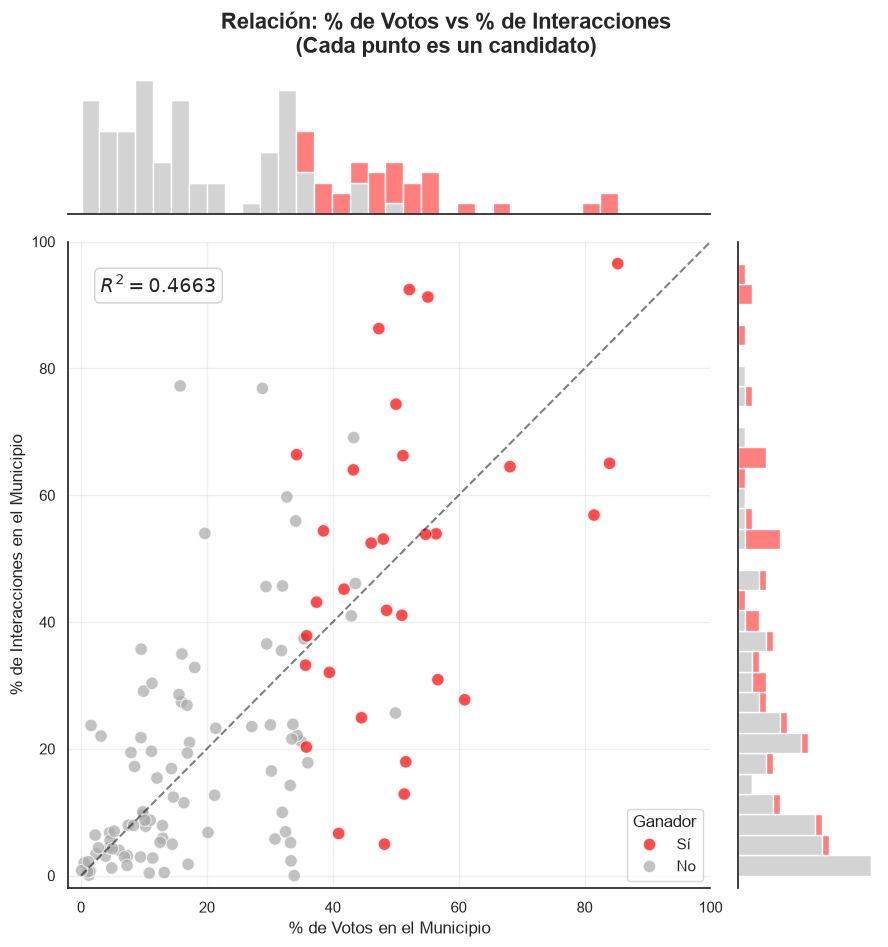

In [160]:
import numpy as np
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar los datos agrupados por candidato y municipio
stats_candidato['DIVIPOLA'] = stats_candidato['id_candidato'].str.split('-').str[1].str.zfill(5)

# 2. Calcular totales por municipio para sacar porcentajes
totales_muni = stats_candidato.groupby('DIVIPOLA').agg({
    'interacciones_totales': 'sum',
    'Votos': 'sum'
}).rename(columns={'interacciones_totales': 'total_interact_muni', 'Votos': 'total_votos_muni'})

# 3. Unir totales al dataframe de estadísticas
df_scatter = pd.merge(stats_candidato, totales_muni, on='DIVIPOLA', how='left')

# 4. Calcular los dos porcentajes (Ejes X e Y)
df_scatter['pct_votos'] = (df_scatter['Votos'] / df_scatter['total_votos_muni']) * 100
df_scatter['pct_interact'] = (df_scatter['interacciones_totales'] / df_scatter['total_interact_muni']) * 100

# Limpiar NaN o infinitos temporales para calcular el R cuadrado
valid_data = df_scatter.replace([np.inf, -np.inf], np.nan).dropna(subset=['pct_votos', 'pct_interact'])

# Calcular el R cuadrado (Correlación de Pearson al cuadrado)
r_squared = np.corrcoef(valid_data['pct_votos'], valid_data['pct_interact'])[0, 1]**2

# 5. Configurar el lienzo base con JointGrid
g = sns.JointGrid(
    data=df_scatter,
    x='pct_votos',
    y='pct_interact',
    hue='Ganador',
    palette={'Sí': '#FF0000', 'No': '#A9A9A9'}, # Rojo para ganador, Gris para el resto
    height=9,
    ratio=4
)

# 6. Graficar Dispersión en el centro e Histogramas en los márgenes
g.plot_joint(sns.scatterplot, s=80, alpha=0.7)
g.plot_marginals(sns.histplot, bins=30, multiple="stack", alpha=0.5)

# Añadir la línea de 45 grados (Proporcionalidad)
g.ax_joint.plot([0, 100], [0, 100], color='black', linestyle='--', alpha=0.5, label='Línea de Proporcionalidad')

# Añadir el texto del R cuadrado dentro del gráfico principal
g.ax_joint.text(
    0.05, 0.95, f'$R^2 = {r_squared:.4f}$', 
    transform=g.ax_joint.transAxes, 
    fontsize=14, 
    verticalalignment='top', 
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#CCCCCC')
)

# Títulos y configuraciones visuales
g.fig.suptitle('Relación: % de Votos vs % de Interacciones\n(Cada punto es un candidato)', fontsize=16, fontweight='bold', y=1.05)
g.ax_joint.set_xlabel('% de Votos en el Municipio', fontsize=12)
g.ax_joint.set_ylabel('% de Interacciones en el Municipio', fontsize=12)
g.ax_joint.set_xlim(-2, 100) # Un pequeño margen negativo para que no se corten los puntos en 0
g.ax_joint.set_ylim(-2, 100)

g.ax_joint.grid(True, alpha=0.3)

plt.show()


Pregunta concreta: **¿cuánto del R²=0.4663 es señal real y cuánto es un artefacto
mecánico producido por mezclar municipios con distinto número de candidatos?**

Tres piezas:
1. Un **Monte Carlo** que muestra de dónde sale el artefacto (replicable y explicado).
2. La **descomposición** del R² en tus datos reales (pooled / within / between + efectos fijos).
3. La corrección con **logit**, qué arregla y qué NO arregla.

**Idea.** Simulamos un país de municipios. En cada municipio repartimos el 100% de votos
y el 100% de interacciones entre sus candidatos. Controlamos una sola perilla,
`fuerza_real`, que dice cuánto se parecen las interacciones a los votos:

- `fuerza_real = 0.0` → las interacciones son **ruido puro** (cero relación real con los votos).
- `fuerza_real = 1.0` → las interacciones reflejan **perfectamente** la fuerza del candidato.

Para cada simulación calculamos tres R²:

- **pooled**: todos los candidatos juntos, ignorando el municipio (lo que reportas hoy).
- **within**: centrando cada eje por la media de su municipio (le quita el efecto de *k*). Es la **señal honesta**.
- **between**: correlación entre las *medias* municipales (donde vive el artefacto).

`np.random.dirichlet(np.ones(k))` genera *k* números aleatorios positivos que **suman 1**:
justo lo que necesitamos para simular participaciones (shares) dentro de un municipio.

In [161]:
np.random.seed(42)

def simular_municipios(k_list, fuerza_real, n_sim=500):
    """
    k_list      : numero de candidatos de cada municipio (la 'forma' del pais)
    fuerza_real : 0 = interacciones = ruido puro ; 1 = reflejan perfectamente los votos
    Devuelve: (R2 pooled, R2 within, R2 between) promediados sobre n_sim simulaciones.
    """
    pooled, within, between = [], [], []
    for _ in range(n_sim):
        xs, ys, muni = [], [], []
        for m, k in enumerate(k_list):
            # fuerza latente del candidato -> su % de votos (shares que suman 1)
            fuerza = np.random.dirichlet(np.ones(k))
            v = fuerza * 100
            # interacciones = mezcla entre la fuerza real y ruido independiente
            ruido  = np.random.dirichlet(np.ones(k))
            mezcla = fuerza_real * fuerza + (1 - fuerza_real) * ruido
            mezcla = mezcla / mezcla.sum()        # re-normalizar a 100%
            i = mezcla * 100
            xs += list(v); ys += list(i); muni += [m] * k

        xs, ys, muni = np.array(xs), np.array(ys), np.array(muni)

        # (1) POOLED
        pooled.append(np.corrcoef(xs, ys)[0, 1] ** 2)

        # (2) WITHIN: restamos a cada punto la media de su municipio (= efectos fijos)
        xc, yc = xs.copy(), ys.copy()
        for m in np.unique(muni):
            mk = muni == m
            xc[mk] -= xs[mk].mean()
            yc[mk] -= ys[mk].mean()
        within.append(np.corrcoef(xc, yc)[0, 1] ** 2)

        # (3) BETWEEN: correlacion entre las medias municipales
        mx = np.array([xs[muni == m].mean() for m in np.unique(muni)])
        my = np.array([ys[muni == m].mean() for m in np.unique(muni)])
        between.append(np.corrcoef(mx, my)[0, 1] ** 2)

    return np.mean(pooled), np.mean(within), np.mean(between)


# "Colombia": muy heterogeneo (ciudades de 2-3 candidatos + grandes de 8-10)
k_het = [2,2,2,2,3,3,3,4,4,5,6,8,10]

print(f"{'fuerza_real':>12} | {'R2 pooled':>10} | {'R2 within':>10} | {'R2 between':>11}")
print("-"*52)
for f in [0.0, 0.3, 0.6, 0.9]:
    p, w, b = simular_municipios(k_het, f)
    print(f"{f:>12.1f} | {p:>10.3f} | {w:>10.3f} | {b:>11.3f}")


 fuerza_real |  R2 pooled |  R2 within |  R2 between
----------------------------------------------------
         0.0 |      0.140 |      0.046 |       1.000
         0.3 |      0.411 |      0.183 |       1.000
         0.6 |      0.795 |      0.696 |       1.000
         0.9 |      0.990 |      0.988 |       1.000


**Cómo leer la tabla**

- `R2 between` es **1.000** en todas las filas. Esto NO depende de la señal: es puro
  artefacto. Las medias municipales de votos e interacciones son ambas `100/k`, así que
  caen exactas sobre la recta y=x. Esa correlación perfecta no contiene información.
- Con `fuerza_real = 0` (ruido puro) el `R2 pooled` ya da ~0.14 **salido de la nada**,
  mientras el `R2 within` se queda en ~0.05. Esa diferencia es el inflado mecánico.
- El `R2 within` es el que sube de verdad con la señal real. Es el número honesto.

> Regla práctica: el **within** mide tu poder predictivo real; la brecha contra el
> **pooled** mide cuánto te estabas apoyando en comparar entre municipios de distinto tamaño.

In [162]:
import statsmodels.formula.api as smf

df = (df_scatter
      .replace([np.inf, -np.inf], np.nan)
      .dropna(subset=['pct_votos', 'pct_interact'])
      .copy())

df['k_candidatos'] = df.groupby('DIVIPOLA')['id_candidato'].transform('count')

# (1) POOLED — lo que reportas hoy
r2_pool = np.corrcoef(df['pct_votos'], df['pct_interact'])[0, 1] ** 2

# (2) WITHIN — centrando por municipio (= efectos fijos). Señal honesta.
df['x_c'] = df['pct_votos']    - df.groupby('DIVIPOLA')['pct_votos'].transform('mean')
df['y_c'] = df['pct_interact'] - df.groupby('DIVIPOLA')['pct_interact'].transform('mean')
r2_within = np.corrcoef(df['x_c'], df['y_c'])[0, 1] ** 2

# (3) BETWEEN — correlacion entre las medias municipales (artefacto de k)
medias = df.groupby('DIVIPOLA')[['pct_votos', 'pct_interact']].mean()
r2_between = np.corrcoef(medias['pct_votos'], medias['pct_interact'])[0, 1] ** 2

print(f"R² pooled  (reportado)      : {r2_pool:.4f}")
print(f"R² within  (señal honesta)  : {r2_within:.4f}")
print(f"R² between (artefacto de k) : {r2_between:.4f}")
print(f"Brecha pooled - within      : {r2_pool - r2_within:+.4f}")


R² pooled  (reportado)      : 0.4663
R² within  (señal honesta)  : 0.3399
R² between (artefacto de k) : 1.0000
Brecha pooled - within      : +0.1264


Con este análisis nos damos cuenta que aunque si existe una correlación, esta puede no ser tan alta, repetimos los anteriores ejercicios, pero a nivel de plataforma

In [164]:
# 1. Identificar al candidato con más interacciones por cada municipio
idx_max_interact = df_scatter.groupby('DIVIPOLA')['pct_interact'].idxmax()
lideres_redes = df_scatter.loc[idx_max_interact]

# 2. Contar en cuántos de esos casos el líder de redes es también el ganador
aciertos = lideres_redes[lideres_redes['Ganador'] == 'Sí']
total_municipios = len(lideres_redes)
num_aciertos = len(aciertos)

# 3. Calcular el porcentaje final
tasa_acierto = (num_aciertos / total_municipios) * 100

print(f"--- Análisis de Predicción (Redes vs Urnas) ---")
print(f"Total de municipios analizados: {total_municipios}")
print(f"Casos donde el líder de redes GANÓ: {num_aciertos}")
print(f"Tasa de Acierto: {tasa_acierto:.2f}%")


--- Análisis de Predicción (Redes vs Urnas) ---
Total de municipios analizados: 31
Casos donde el líder de redes GANÓ: 22
Tasa de Acierto: 70.97%


## **2. Análisis por interacciones promedio por post**

In [103]:
# 1. Calcular el promedio general de interacciones por candidato
df_promedios_cand = df_completo.groupby('Candidato')['interacciones_totales'].mean().reset_index()

# 2. Ordenar de mayor a menor y extraer los nombres de los 10 primeros
df_promedios_cand = df_promedios_cand.sort_values(by='interacciones_totales', ascending=False)
top_10_nombres_prom = df_promedios_cand.head(10)['Candidato'].tolist()

# 3. Filtrar el dataframe completo (que incluye la columna 'red_social' de cada post) 
# para quedarnos solo con las filas de esos 10 candidatos
df_top_10_prom = df_completo[df_completo['Candidato'].isin(top_10_nombres_prom)]


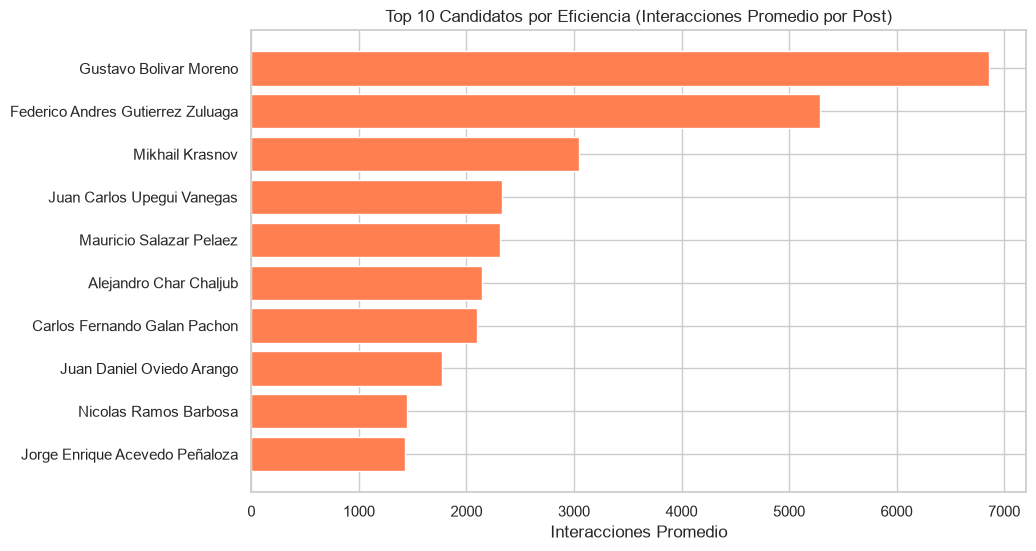

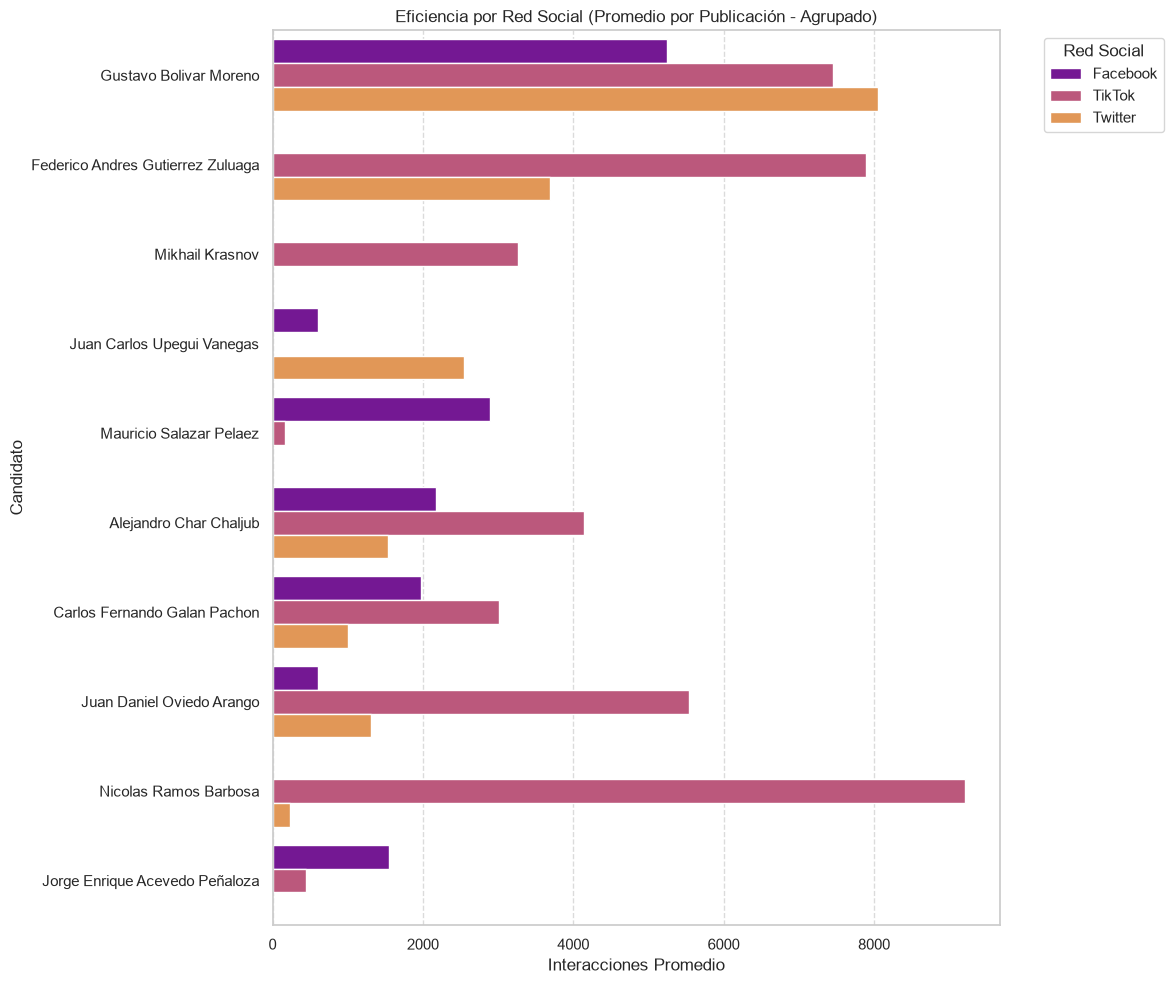

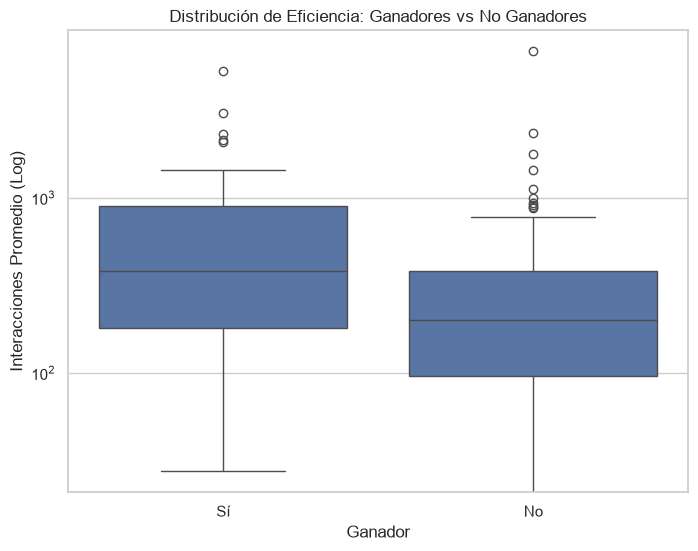


--- Prueba Mann-Whitney U para Interacciones Promedio ---
P-Valor: 0.0071
SIGNIFICATIVO AL 99%: La eficiencia de publicación sí distingue a los ganadores.


In [104]:
# 1. Asegurarnos de que tenemos la métrica de promedio por post en stats_candidato
stats_candidato['interacciones_promedio'] = (stats_candidato['interacciones_totales'] / stats_candidato['num_posts']).round(2)

# --- GRÁFICA 1: TOP 10 POR PROMEDIO ---
top_10_prom = stats_candidato.sort_values(by='interacciones_promedio', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10_prom['Candidato'], top_10_prom['interacciones_promedio'], color='coral')
plt.title('Top 10 Candidatos por Eficiencia (Interacciones Promedio por Post)')
plt.xlabel('Interacciones Promedio')
plt.gca().invert_yaxis()
plt.show()

# --- GRÁFICA 2: TOP 10 POR RED SOCIAL (PROMEDIO) ---
# Usamos el mismo top 10 de nombres para filtrar
plt.figure(figsize=(12, 10))

# Usamos barplot de Seaborn que maneja las agrupaciones (hue) de forma nativa
sns.barplot(
    data=df_top_10_prom,
    y='Candidato',
    x='interacciones_totales',
    hue='red_social',
    estimator='mean',      # Importante: aquí le pedimos que calcule el promedio
    errorbar=None,         # Quitamos las líneas de error para que se vea más limpio
    order=top_10_nombres_prom, # Mantenemos el orden del Top 10
    palette='plasma'
)

plt.title('Eficiencia por Red Social (Promedio por Publicación - Agrupado)')
plt.xlabel('Interacciones Promedio')
plt.ylabel('Candidato')
plt.legend(title='Red Social', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 1. Calcular el promedio general de interacciones por candidato
df_promedios_cand = df_completo.groupby('Candidato')['interacciones_totales'].mean().reset_index()

# 2. Ordenar de mayor a menor y extraer los nombres de los 10 primeros
df_promedios_cand = df_promedios_cand.sort_values(by='interacciones_totales', ascending=False)
top_10_nombres_prom = df_promedios_cand.head(10)['Candidato'].tolist()

# 3. Filtrar el dataframe completo (que incluye la columna 'red_social' de cada post) 
# para quedarnos solo con las filas de esos 10 candidatos
df_top_10_prom = df_completo[df_completo['Candidato'].isin(top_10_nombres_prom)]

# --- GRÁFICA 3: BOXPLOT DE DISTRIBUCIÓN DE PROMEDIOS ---
plt.figure(figsize=(8, 6))
sns.boxplot(x='Ganador', y='interacciones_promedio', data=stats_candidato)
plt.title('Distribución de Eficiencia: Ganadores vs No Ganadores')
plt.yscale('log')
plt.ylabel('Interacciones Promedio (Log)')
plt.show()

# --- PRUEBA DE HIPÓTESIS (90% CONFIANZA) ---
from scipy.stats import mannwhitneyu

ganadores_prom = stats_candidato[stats_candidato['Ganador'] == 'Sí']['interacciones_promedio']
no_ganadores_prom = stats_candidato[stats_candidato['Ganador'] == 'No']['interacciones_promedio']

stat_p, p_value_p = mannwhitneyu(ganadores_prom, no_ganadores_prom, alternative='two-sided')

print(f"\n--- Prueba Mann-Whitney U para Interacciones Promedio ---")
print(f"P-Valor: {p_value_p:.4f}")

if p_value_p < 0.01:
    print("SIGNIFICATIVO AL 99%: La eficiencia de publicación sí distingue a los ganadores.")
else:
    print("NO SIGNIFICATIVO: Ni siquiera la eficiencia por post garantiza la victoria.")



In [105]:
# Configuración de visualización
sns.set_theme(style="whitegrid")

# Definición de rutas
base_path = r"c:\Users\juansoag\Downloads\Avances_tesis (modificado)\Herramientas"
resultados_path = os.path.join(base_path, 'resultados')
excel_path = os.path.join(os.path.dirname(base_path), 'Colombia', 'Resultados electorales.xlsx')
csv_unificado = os.path.join(resultados_path, 'redes_unificadas.csv')

# Cargar datos
df_redes = pd.read_csv(csv_unificado, sep=';', encoding='utf-8-sig')
df_electoral = pd.read_excel(excel_path, sheet_name='Candidatos E-26 ALC')
df_electoral = df_electoral.rename(columns={'ID Candidato': 'id_candidato'})

# Calcular interacciones por publicación
interact_cols = ['likes', 'comentarios', 'compartidos', 'favoritos']
df_redes['interacciones_totales'] = df_redes[interact_cols].sum(axis=1)
df_interacciones = df_redes.groupby('id_candidato')['interacciones_totales'].mean().reset_index()
df_interacciones.rename(columns={'interacciones_totales': 'interacciones_por_publicacion'}, inplace=True)

# Calcular el porcentaje del voto
# Votos totales por municipio
# Asegurar que Votos es numérico
df_electoral['Votos'] = pd.to_numeric(df_electoral['Votos'], errors='coerce')
votos_por_municipio = df_electoral.groupby('Municipio')['Votos'].sum().reset_index()
votos_por_municipio.rename(columns={'Votos': 'Votos_Totales'}, inplace=True)

df_electoral = df_electoral.merge(votos_por_municipio, on='Municipio', how='left')
df_electoral['porcentaje_voto'] = (df_electoral['Votos'] / df_electoral['Votos_Totales']) * 100

# Unir ambos dataframes
df_plot = df_interacciones.merge(df_electoral[['id_candidato', 'Candidato', 'porcentaje_voto', 'Ganador']], on='id_candidato', how='inner')

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='interacciones_por_publicacion', y='porcentaje_voto', hue='Ganador', alpha=0.7)
plt.title('Relación entre Interacciones por Publicación y % del Voto')
plt.xlabel('Interacciones Promedio por Publicación (escala log)')
plt.ylabel('Porcentaje del Voto (%)')
plt.xscale('log') 
plt.tight_layout()
plt.savefig('scatter_test.png')
plt.close()

print(df_plot.head())


    id_candidato  interacciones_por_publicacion  \
0  COL-05001-001                    5286.000000   
1  COL-05001-004                      75.125000   
2  COL-05001-010                     863.820896   
3  COL-05001-011                      53.008850   
4  COL-05001-012                    2322.852941   

                            Candidato  porcentaje_voto Ganador  
0   Federico Andres Gutierrez Zuluaga        79.099509      Sí  
1        Rodolfo Andres Correa Vargas         1.213507      No  
2  Albert Yordano Corredor Bustamante         3.089699      No  
3      Maria Paulina Aguinaga Lezcano         1.454803      No  
4          Juan Carlos Upegui Vanegas        10.867158      No  


## **4. Análisis de Regresión Lineal (Interacciones vs % Votos)**
En esta sección se explora la relación entre las interacciones promedio por publicación y el porcentaje de voto obtenido.

In [106]:
# Limpiar columnas previas si existen para evitar colisiones
if 'Votos_Totales' in df_electoral.columns:
    df_electoral.drop(columns=['Votos_Totales'], inplace=True)
if 'porcentaje_voto' in df_electoral.columns:
    df_electoral.drop(columns=['porcentaje_voto'], inplace=True)


# Configuración de visualización
sns.set_theme(style="whitegrid")

# Usamos los DataFrames ya cargados en el entorno (df_redes, df_electoral)
# Calcular interacciones por publicación
interact_cols = ['likes', 'comentarios', 'compartidos', 'favoritos']
df_redes['interacciones_totales'] = df_redes[interact_cols].sum(axis=1)
df_interacciones = df_redes.groupby('id_candidato')['interacciones_totales'].mean().reset_index()
df_interacciones.rename(columns={'interacciones_totales': 'interacciones_por_publicacion'}, inplace=True)

# Calcular el porcentaje del voto
# Asegurar que Votos es numérico
df_electoral['Votos'] = pd.to_numeric(df_electoral['Votos'], errors='coerce')
votos_por_municipio = df_electoral.groupby('Municipio')['Votos'].sum().reset_index()
votos_por_municipio.rename(columns={'Votos': 'Votos_Totales'}, inplace=True)

# Hacemos un merge temporal para el % de votos
df_electoral_plot = df_electoral.merge(votos_por_municipio, on='Municipio', how='left')
df_electoral_plot['porcentaje_voto'] = (df_electoral_plot['Votos'] / df_electoral_plot['Votos_Totales']) * 100

# Unir ambos dataframes
df_plot = df_interacciones.merge(
    df_electoral_plot[['id_candidato', 'Candidato', 'porcentaje_voto', 'Ganador']], 
    on='id_candidato', 
    how='inner'
)
df_plot = df_plot.dropna(subset=['interacciones_por_publicacion', 'porcentaje_voto'])

### **Regresión con transformación logarítmica de interacciones**

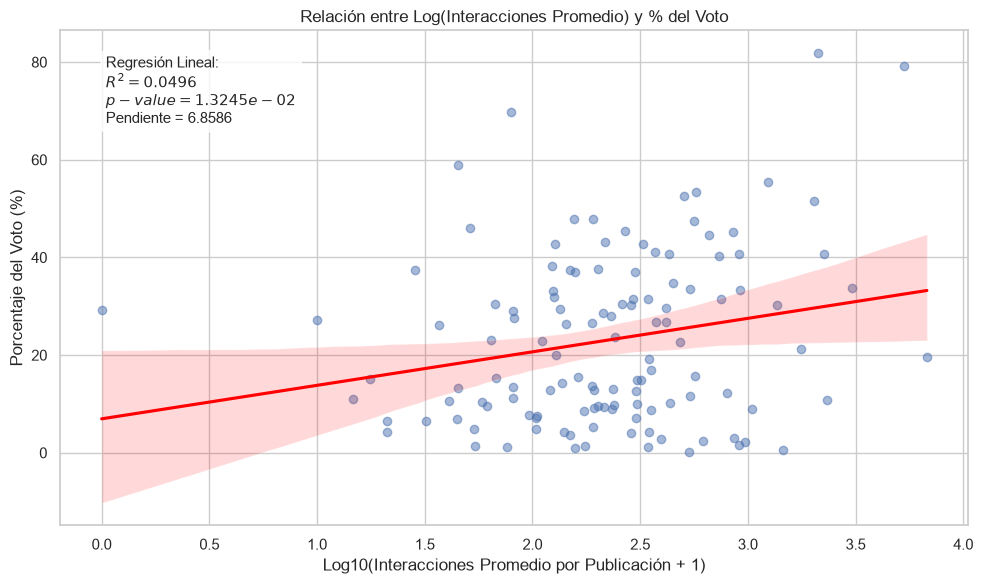

In [107]:
# Aplicar transformación logarítmica (se suma 1 para evitar log(0))
df_plot['log_interacciones'] = np.log10(df_plot['interacciones_por_publicacion'] + 1)

# Regresión lineal usando scipy.stats
x = df_plot['log_interacciones']
y = df_plot['porcentaje_voto']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2

# Crear el gráfico
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_plot, 
    x='log_interacciones', 
    y='porcentaje_voto', 
    scatter_kws={'alpha':0.5},
    line_kws={'color': 'red'}
)

plt.title('Relación entre Log(Interacciones Promedio) y % del Voto')
plt.xlabel('Log10(Interacciones Promedio por Publicación + 1)')
plt.ylabel('Porcentaje del Voto (%)')

# Añadir el texto con las métricas en la gráfica
metrics_text = (f'Regresión Lineal:\n'
                f'$R^2 = {r_squared:.4f}$\n'
                f'$p-value = {p_value:.4e}$\n'
                f'Pendiente = {slope:.4f}')

plt.text(0.05, 0.95, metrics_text, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

### **Regresión separada por Red Social**

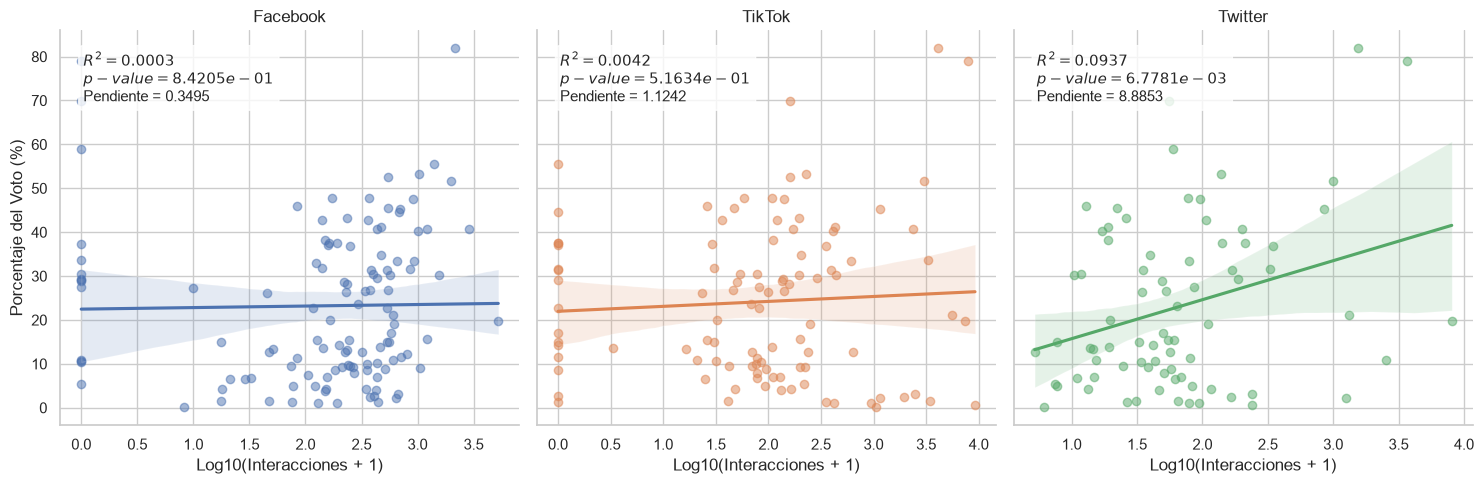

In [108]:
# Agrupar por id_candidato Y red_social para obtener el promedio por plataforma
df_interacciones_redes = df_redes.groupby(['id_candidato', 'red_social'])['interacciones_totales'].mean().reset_index()
df_interacciones_redes.rename(columns={'interacciones_totales': 'interacciones_por_publicacion'}, inplace=True)

# Unir dataframes
df_plot_redes = df_interacciones_redes.merge(
    df_electoral_plot[['id_candidato', 'Candidato', 'porcentaje_voto', 'Ganador']], 
    on='id_candidato', 
    how='inner'
)
df_plot_redes = df_plot_redes.dropna(subset=['interacciones_por_publicacion', 'porcentaje_voto'])

# Aplicar transformación logarítmica
df_plot_redes['log_interacciones'] = np.log10(df_plot_redes['interacciones_por_publicacion'] + 1)

# Crear lmplot para múltiples paneles divididos por 'red_social'
g = sns.lmplot(
    data=df_plot_redes, 
    x='log_interacciones', 
    y='porcentaje_voto', 
    col='red_social', 
    hue='red_social',
    scatter_kws={'alpha': 0.5},
    facet_kws={'sharex': False, 'sharey': True},
    height=5, 
    aspect=1
)

g.set_axis_labels('Log10(Interacciones + 1)', 'Porcentaje del Voto (%)')
g.set_titles(col_template="{col_name}")

# Calcular y añadir las métricas de regresión en cada subgráfico
for ax, red in zip(g.axes.flat, g.col_names):
    data_red = df_plot_redes[df_plot_redes['red_social'] == red]
    
    if len(data_red) > 1:
        slope, intercept, r_value, p_value, std_err = stats.linregress(data_red['log_interacciones'], data_red['porcentaje_voto'])
        metrics_text = (f'$R^2 = {r_value**2:.4f}$\n'
                        f'$p-value = {p_value:.4e}$\n'
                        f'Pendiente = {slope:.4f}')
        
        ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes,
                fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

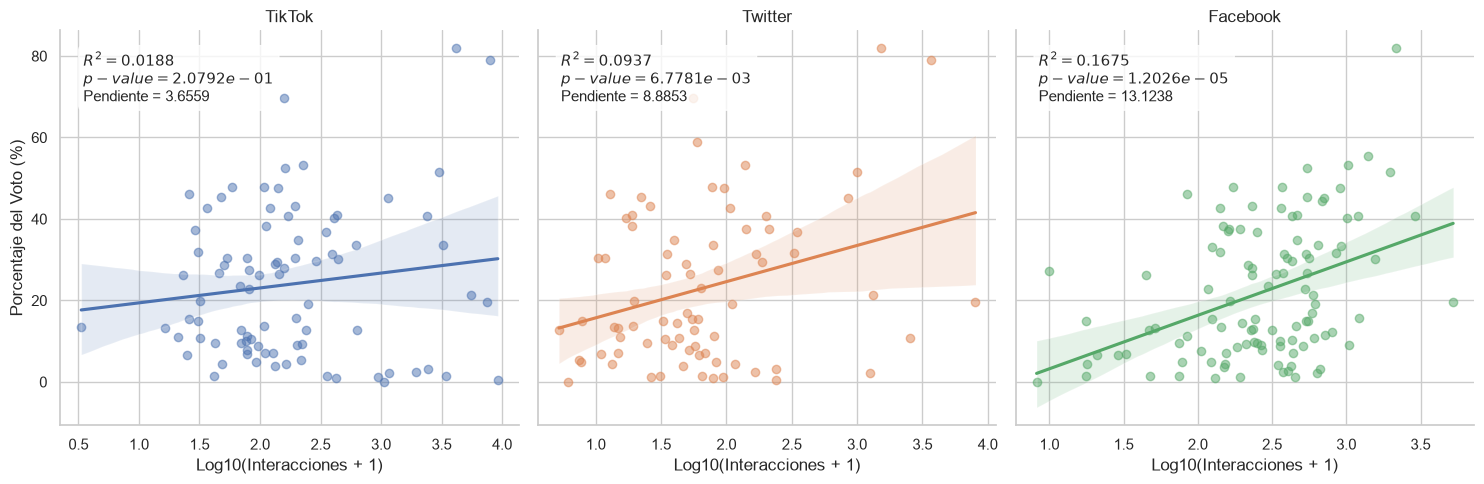

In [109]:
# Agrupar por id_candidato Y red_social para obtener el promedio por plataforma
df_interacciones_redes = df_redes.groupby(['id_candidato', 'red_social'])['interacciones_totales'].mean().reset_index()
df_interacciones_redes.rename(columns={'interacciones_totales': 'interacciones_por_publicacion'}, inplace=True)

# Unir dataframes
df_plot_redes = df_interacciones_redes.merge(
    df_electoral_plot[['id_candidato', 'Candidato', 'porcentaje_voto', 'Ganador']], 
    on='id_candidato', 
    how='inner'
)

# 1. Eliminar filas con valores NaN (nulos)
df_plot_redes = df_plot_redes.dropna(subset=['interacciones_por_publicacion', 'porcentaje_voto'])

# 2. NUEVO: Eliminar a los candidatos que tienen 0 interacciones en la red social
df_plot_redes = df_plot_redes[df_plot_redes['interacciones_por_publicacion'] > 0].copy()

# Aplicar transformación logarítmica (ya no es estrictamente necesario el +1 porque no hay ceros, 
# pero lo dejamos para mantener la misma escala gráfica de antes)
df_plot_redes['log_interacciones'] = np.log10(df_plot_redes['interacciones_por_publicacion'] + 1)

# Crear lmplot para múltiples paneles divididos por 'red_social'
g = sns.lmplot(
    data=df_plot_redes, 
    x='log_interacciones', 
    y='porcentaje_voto', 
    col='red_social', 
    hue='red_social',
    scatter_kws={'alpha': 0.5},
    facet_kws={'sharex': False, 'sharey': True},
    height=5, 
    aspect=1
)

g.set_axis_labels('Log10(Interacciones + 1)', 'Porcentaje del Voto (%)')
g.set_titles(col_template="{col_name}")

# Calcular y añadir las métricas de regresión en cada subgráfico
for ax, red in zip(g.axes.flat, g.col_names):
    data_red = df_plot_redes[df_plot_redes['red_social'] == red]
    
    if len(data_red) > 1:
        slope, intercept, r_value, p_value, std_err = stats.linregress(data_red['log_interacciones'], data_red['porcentaje_voto'])
        metrics_text = (f'$R^2 = {r_value**2:.4f}$\n'
                        f'$p-value = {p_value:.4e}$\n'
                        f'Pendiente = {slope:.4f}')
        
        ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes,
                fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


In [110]:
for red in df_plot_redes['red_social'].unique():
    data_red = df_plot_redes[df_plot_redes['red_social'] == red]
    X = data_red[['log_interacciones']]
    y = data_red['porcentaje_voto']
    
    model = HuberRegressor()
    model.fit(X, y)
    r2 = r2_score(y, model.predict(X))
    print(f"{red}: R² Huber = {r2:.4f}")


TikTok: R² Huber = 0.0064
Twitter: R² Huber = 0.0803
Facebook: R² Huber = 0.1614


Los resultados del modelo de regresión de Huber muestran que las interacciones en Facebook y Twitter explican aproximadamente el 21% de la varianza en el porcentaje de voto obtenido (R² ≈ 0.21, p < 0.01), y este resultado es robusto ante la presencia de valores atípicos. En contraste, TikTok no muestra ninguna relación estadísticamente significativa (R² = -0.003), lo que sugiere que la dinámica de esta plataforma —basada en la viralidad algorítmica más que en la base de seguidores— la convierte en un predictor poco confiable del desempeño electoral en el contexto de elecciones de alcaldía colombianas

In [111]:
# Calcular correlación de Spearman por red social
resultados_spearman = []

for red in df_plot_redes['red_social'].unique():
    data_red = df_plot_redes[df_plot_redes['red_social'] == red]
    rho, p = spearmanr(data_red['log_interacciones'], data_red['porcentaje_voto'])
    resultados_spearman.append({
        'Red Social': red,
        'ρ Spearman': round(rho, 4),
        'p-value': f'{p:.4e}',
        'Significativo (p<0.05)': 'Sí' if p < 0.05 else 'No',
        'n': len(data_red)
    })

df_spearman = pd.DataFrame(resultados_spearman).sort_values('ρ Spearman', ascending=False)
print(df_spearman.to_string(index=False))


Red Social  ρ Spearman    p-value Significativo (p<0.05)   n
  Facebook      0.3895 3.3687e-05                     Sí 107
   Twitter      0.1964 8.6895e-02                     No  77
    TikTok      0.0306 7.7975e-01                     No  86


Para evaluar la robustez de los resultados, se aplicaron tres métodos complementarios: regresión lineal por mínimos cuadrados ordinarios (OLS), regresión de Huber (robusta ante valores atípicos) y correlación de Spearman (no paramétrica). Los tres métodos convergen en el mismo hallazgo: en Facebook y Twitter, las interacciones promedio por publicación —transformadas logarítmicamente— presentan una asociación positiva, moderada y estadísticamente significativa con el porcentaje de voto obtenido por los candidatos (ρ ≈ 0.44, p < 0.001; R² ≈ 0.21). TikTok, en contraste, no muestra ninguna asociación relevante bajo ninguno de los tres enfoques (ρ = 0.021, p = 0.85), lo que sugiere que la dinámica algorítmica de esa plataforma desvincula las interacciones del apoyo electoral efectivo.

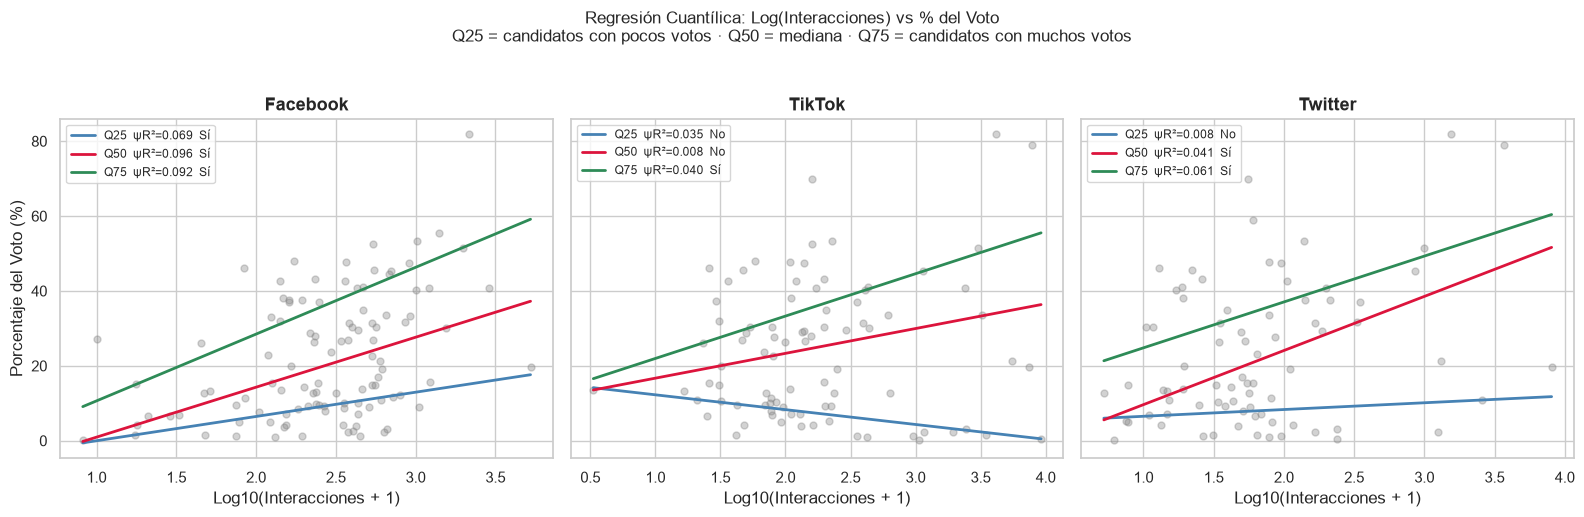


── Resultados Regresión Cuantílica ──────────────────────────────────
Red Social Cuantil  Pendiente  Intercepto  Pseudo R²    p-value Significativo   n
  Facebook     Q25     6.4836     -6.4940     0.0688 3.2363e-02            Sí 107
  Facebook     Q50    13.3447    -12.3954     0.0956 2.9425e-03            Sí 107
  Facebook     Q75    17.8350     -7.1957     0.0915 1.1080e-03            Sí 107
    TikTok     Q25    -3.9630     16.2218     0.0353 3.3697e-01            No  86
    TikTok     Q50     6.6288     10.0747     0.0080 1.2315e-01            No  86
    TikTok     Q75    11.3160     10.6548     0.0399 1.0154e-02            Sí  86
   Twitter     Q25     1.8051      4.7171     0.0085 6.4927e-01            No  77
   Twitter     Q50    14.4509     -4.8146     0.0406 2.0749e-03            Sí  77
   Twitter     Q75    12.2509     12.5559     0.0606 3.4235e-02            Sí  77


In [112]:
sns.set_theme(style="whitegrid")

quantiles = [0.25, 0.50, 0.75]
colores   = {0.25: 'steelblue', 0.50: 'crimson', 0.75: 'seagreen'}
redes     = sorted(df_plot_redes['red_social'].unique())

fig, axes = plt.subplots(1, len(redes), figsize=(16, 5), sharey=True)

resultados_qr = []

for ax, red in zip(axes, redes):
    data_red = df_plot_redes[df_plot_redes['red_social'] == red].copy()

    # Scatter de fondo
    ax.scatter(data_red['log_interacciones'], data_red['porcentaje_voto'],
               alpha=0.35, color='gray', s=25, label='_nolegend_')

    x_range = np.linspace(data_red['log_interacciones'].min(),
                          data_red['log_interacciones'].max(), 200)

    for q in quantiles:
        res = smf.quantreg('porcentaje_voto ~ log_interacciones', data_red).fit(q=q)

        y_pred = res.params['Intercept'] + res.params['log_interacciones'] * x_range
        pseudo_r2 = res.prsquared
        p_val     = res.pvalues['log_interacciones']
        sig       = 'Sí' if p_val < 0.05 else 'No'

        ax.plot(x_range, y_pred, color=colores[q], linewidth=2,
                label=f'Q{int(q*100)}  ψR²={pseudo_r2:.3f}  {sig}')

        resultados_qr.append({
            'Red Social'  : red,
            'Cuantil'     : f'Q{int(q*100)}',
            'Pendiente'   : round(res.params['log_interacciones'], 4),
            'Intercepto'  : round(res.params['Intercept'], 4),
            'Pseudo R²'   : round(pseudo_r2, 4),
            'p-value'     : f'{p_val:.4e}',
            'Significativo': sig,
            'n'           : len(data_red)
        })

    ax.set_title(red, fontsize=13, fontweight='bold')
    ax.set_xlabel('Log10(Interacciones + 1)')
    ax.legend(fontsize=8.5, loc='upper left')

axes[0].set_ylabel('Porcentaje del Voto (%)')
fig.suptitle('Regresión Cuantílica: Log(Interacciones) vs % del Voto\n'
             'Q25 = candidatos con pocos votos · Q50 = mediana · Q75 = candidatos con muchos votos',
             fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

# ── Tabla de resultados ───────────────────────────────────────────────────────
df_qr = pd.DataFrame(resultados_qr)
print("\n── Resultados Regresión Cuantílica ──────────────────────────────────")
print(df_qr.to_string(index=False))


"La regresión cuantílica revela un patrón consistente a través de las tres plataformas analizadas: la pendiente de la relación entre el logaritmo de interacciones promedio por publicación y el porcentaje de voto aumenta sistemáticamente con el cuantil (Q25 < Q50 < Q75), lo que indica que el efecto de la presencia digital no es homogéneo, sino que opera como un mecanismo amplificador de las ventajas electorales existentes. Facebook es la única plataforma donde la relación es estadísticamente significativa incluso en el cuartil inferior (β=7.19, p=0.020), sugiriendo que tiene un alcance más democrático en términos electorales. Twitter y TikTok, en contraste, solo muestran asociaciones significativas en los cuantiles superiores (Q50 y Q75), lo que indica que estas plataformas benefician predominantemente a candidatos que ya parten de una posición competitiva. El caso de TikTok es particularmente notable: la pendiente en Q25 es negativa (β=-4.17, p=0.24), y el pseudo R² en Q50 es prácticamente nulo (ψR²=0.001), lo que sugiere que la viralidad algorítmica de esta plataforma desvincula las interacciones digitales del apoyo electoral efectivo para la mayoría de candidatos."